# Telco Customer Churn - End-to-End

A complete, from-scratch walkthrough: explore the data, find issues and act on them,
engineer features, compare models, tune with Optuna, choose a decision threshold by
business value, explain predictions with SHAP, validate with a data contract, and track
everything in MLflow. Read it top to bottom to see each decision being made - and why.

In [1]:
import warnings
warnings.filterwarnings("ignore")   # keep the notebook output clean

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")           # run from repo root so data/ resolves
raw = pd.read_csv("data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
raw.shape

(7043, 21)

In [3]:
raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis

We understand the data *before* touching it: structure, quality, distributions, and how each feature relates to churn.

## 1. Structure & types

In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observations:**
- 7043 rows x 21 columns, one row per customer.
- 18 columns are `object` (text) - mostly categorical.
- `tenure` and `MonthlyCharges` are numeric; `SeniorCitizen` is already 0/1.
- **`TotalCharges` is `object`** though it should be numeric - investigated in section 4.

In [5]:
raw.describe(include='number')

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. The target: `Churn`

In [6]:
raw['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
print('Churn rate: %.1f%%' % (100 * (raw['Churn'] == 'Yes').mean()))

Churn rate: 26.5%


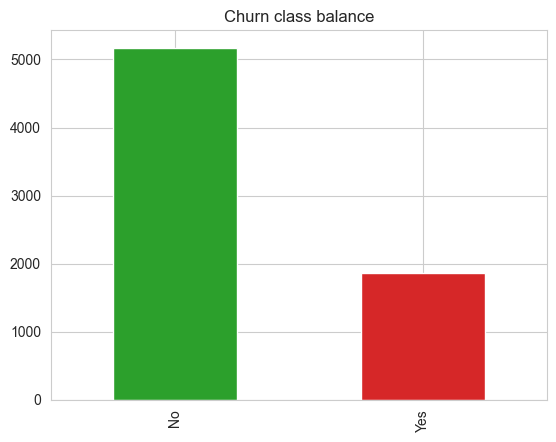

In [8]:
raw['Churn'].value_counts().plot.bar(color=['#2ca02c', '#d62728'])
plt.title('Churn class balance'); plt.xlabel(''); plt.show()

**Observation:** imbalanced (~26.5% churn) -> accuracy is misleading; we'll need class weighting and a tuned threshold (recall on churners matters).

## 3. Data quality - duplicates and missing values

In [9]:
print('Fully duplicated rows :', int(raw.duplicated().sum()))
print('Duplicate customerIDs :', int(raw['customerID'].duplicated().sum()))

Fully duplicated rows : 0
Duplicate customerIDs : 0


In [10]:
raw.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

`isnull()` reports **zero** missing - but 18 columns are text, and text columns hide
"missing" values as blank / whitespace strings that `isnull()` does not count. So I check
**every** object column for blanks rather than trust `isnull()`.

In [11]:
obj_cols = raw.select_dtypes(include='object').columns
blanks = pd.Series({c: int((raw[c].astype(str).str.strip() == '').sum()) for c in obj_cols})
blanks.sort_values(ascending=False)

TotalCharges        11
customerID           0
gender               0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
DeviceProtection     0
OnlineBackup         0
OnlineSecurity       0
InternetService      0
MultipleLines        0
PhoneService         0
Dependents           0
Partner              0
Churn                0
dtype: int64

**Finding:** only **`TotalCharges`** has hidden blanks (11); every other text column is
clean. So the data-quality issue is isolated to `TotalCharges`, which we dissect in section 4.

## 4. Categorical columns - cardinality & exact categories

In [12]:
raw[obj_cols].nunique().sort_values()

Churn                  2
gender                 2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
MultipleLines          3
DeviceProtection       3
PaymentMethod          4
TotalCharges        6531
customerID          7043
dtype: int64

In [13]:
# Print the actual categories of each categorical column (skip the ID and the numeric-as-text one).
for c in obj_cols:
    if c in ('customerID', 'TotalCharges'):
        continue
    print(f"{c:18s} ({raw[c].nunique()}): {sorted(raw[c].unique())}")

gender             (2): ['Female', 'Male']
Partner            (2): ['No', 'Yes']
Dependents         (2): ['No', 'Yes']
PhoneService       (2): ['No', 'Yes']
MultipleLines      (3): ['No', 'No phone service', 'Yes']
InternetService    (3): ['DSL', 'Fiber optic', 'No']
OnlineSecurity     (3): ['No', 'No internet service', 'Yes']
OnlineBackup       (3): ['No', 'No internet service', 'Yes']
DeviceProtection   (3): ['No', 'No internet service', 'Yes']
TechSupport        (3): ['No', 'No internet service', 'Yes']
StreamingTV        (3): ['No', 'No internet service', 'Yes']
StreamingMovies    (3): ['No', 'No internet service', 'Yes']
Contract           (3): ['Month-to-month', 'One year', 'Two year']
PaperlessBilling   (2): ['No', 'Yes']
PaymentMethod      (4): ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn              (2): ['No', 'Yes']


**Observations:**
- `customerID` is unique per row (7043) - an identifier, not a feature -> drop later.
- Categories are clean (no typos/garbage); binaries are Yes/No or Male/Female.
- Several columns carry structural levels like **"No internet service"** /
  **"No phone service"** - these are *deterministically* tied to `InternetService` /
  `PhoneService`, which is exactly what will drive the perfect collinearity we see in the
  VIF step (section 9).

## 5. The `TotalCharges` anomaly (deep dive)

It is text because of those 11 blanks. Coerce to numeric and look at exactly which
customers fail to parse.

In [14]:
total_numeric = pd.to_numeric(raw['TotalCharges'], errors='coerce')
print('Rows that fail to parse as a number:', int(total_numeric.isna().sum()))

Rows that fail to parse as a number: 11


In [15]:
raw.loc[total_numeric.isna(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [16]:
print('tenure of the blank-TotalCharges rows:', sorted(raw.loc[total_numeric.isna(), 'tenure'].unique()))

tenure of the blank-TotalCharges rows: [0]


**Finding & decision.** All 11 blank rows have **`tenure = 0`** - brand-new customers who
haven't completed a billing cycle, so their total charged so far is genuinely ~**0**. I
fill these with **0** (imputing the median would falsely imply a long-standing customer).

## 6. Numeric feature distributions

In [17]:
# Work on a numeric-coerced copy for the numeric EDA.
num_df = raw.copy()
num_df['TotalCharges'] = pd.to_numeric(num_df['TotalCharges'], errors='coerce')
num_df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


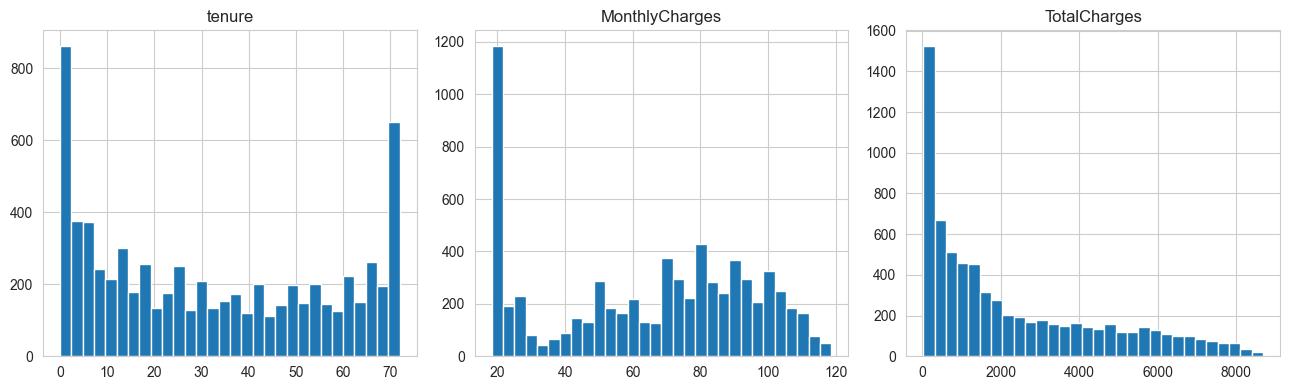

In [18]:
num_df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(bins=30, figsize=(13, 4), layout=(1, 3))
plt.tight_layout(); plt.show()

In [19]:
print('SeniorCitizen share:')
print((raw['SeniorCitizen'].value_counts(normalize=True) * 100).round(1))

SeniorCitizen share:
SeniorCitizen
0    83.8
1    16.2
Name: proportion, dtype: float64


**Observations:** `tenure` is U-shaped (many brand-new and many long-tenured customers);
`MonthlyCharges` is bimodal (low-cost DSL vs higher-cost fiber); `TotalCharges` is
right-skewed (a function of tenure x monthly). Only ~16% of customers are seniors.

## 7. Numeric features vs churn

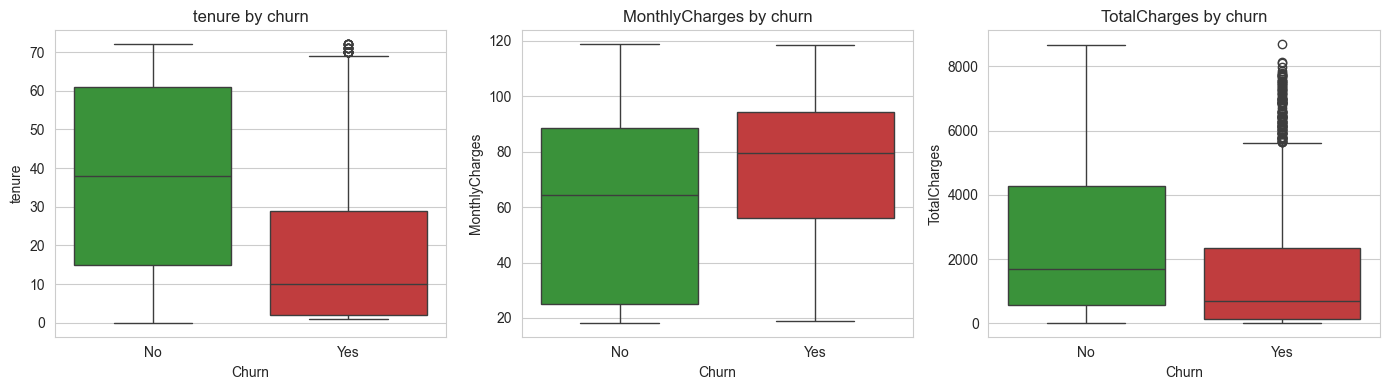

In [20]:
tmp = num_df.copy(); tmp['Churn'] = raw['Churn']
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(data=tmp, x='Churn', y=col, hue='Churn', legend=False,
                palette=['#2ca02c', '#d62728'], ax=ax[i])
    ax[i].set_title(f'{col} by churn')
plt.tight_layout(); plt.show()

**Observation:** churners have markedly **lower tenure** and **higher monthly charges** -
new, expensive customers are the flight risk. `TotalCharges` is lower for churners (a
consequence of short tenure).

## 8. Categorical features vs churn

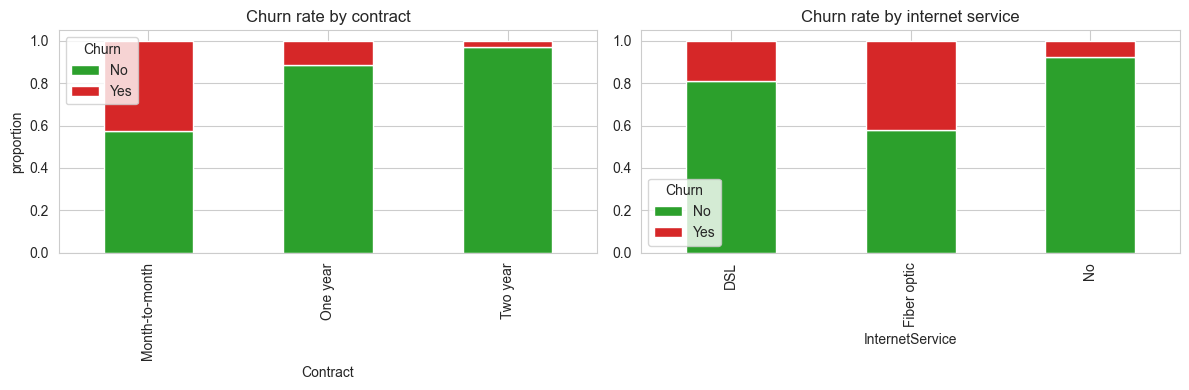

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
pd.crosstab(raw['Contract'], raw['Churn'], normalize='index').plot.bar(
    stacked=True, color=['#2ca02c', '#d62728'], ax=ax[0])
ax[0].set_title('Churn rate by contract'); ax[0].set_ylabel('proportion'); ax[0].legend(title='Churn')
pd.crosstab(raw['InternetService'], raw['Churn'], normalize='index').plot.bar(
    stacked=True, color=['#2ca02c', '#d62728'], ax=ax[1])
ax[1].set_title('Churn rate by internet service'); ax[1].legend(title='Churn')
plt.tight_layout(); plt.show()

In [22]:
# Churn rate (%) across several categoricals at a glance.
churn01 = (raw['Churn'] == 'Yes').astype(int)
for c in ['PaymentMethod', 'SeniorCitizen', 'Partner', 'Dependents', 'TechSupport']:
    print(c)
    print((churn01.groupby(raw[c]).mean() * 100).round(1).to_string())
    print()

PaymentMethod
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1

SeniorCitizen
SeniorCitizen
0    23.6
1    41.7

Partner
Partner
No     33.0
Yes    19.7

Dependents
Dependents
No     31.3
Yes    15.5

TechSupport
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2



**Observations:** churn is highest for **month-to-month** contracts, **fiber-optic**
internet, **electronic-check** payment, **seniors**, and customers **without** partners /
dependents / tech support. These line up with the correlations we compute next.

# Data preparation

## 9. Cleaning - turning the EDA findings into code

In [23]:
df = raw.copy()
df.columns = df.columns.str.strip()      # tidy any stray header whitespace
df = df.drop(columns=['customerID'])      # identifier, not a predictor (from section 4)
df.shape

(7043, 20)

In [24]:
# Apply the section 5 finding: coerce TotalCharges, fill the tenure-0 blanks with 0.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
print('Remaining NaNs in TotalCharges:', int(df['TotalCharges'].isna().sum()))

Remaining NaNs in TotalCharges: 0


In [25]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1}).astype(int)   # target -> 0/1
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].describe()

,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.265370
std,24.559481,30.090047,2266.794470,0.441561
min,0.000000,18.250000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000
max,72.000000,118.750000,8684.800000,1.000000


## 10. Encoding the categoricals

Binary (2 categories) -> 0/1; multi-category -> one-hot.

In [26]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
binary_cols = [c for c in cat_cols if df[c].nunique() == 2]
multi_cols = [c for c in cat_cols if df[c].nunique() > 2]
print('Binary :', binary_cols)
print('Multi  :', multi_cols)

Binary : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi  : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [27]:
df_enc = df.copy()
binmap = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for c in binary_cols:
    df_enc[c] = df_enc[c].map(binmap)
df_enc[binary_cols].head(3)

,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1


In [28]:
df_enc = pd.get_dummies(df_enc, columns=multi_cols, drop_first=True)
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)
print('Encoded shape:', df_enc.shape)
df_enc.head(3)

Encoded shape: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1


> **Watch out - a train/serve skew trap.** `drop_first=True` is fine on the full training
> table, but encoding **one customer at a time** with `pd.get_dummies(drop_first=True)`
> behaves differently. Watch what happens to a single Fiber-optic customer:

In [29]:
one = df.iloc[[4]][['InternetService']]        # a single Fiber-optic customer
print('Original value:', one['InternetService'].iloc[0])
display(pd.get_dummies(one, columns=['InternetService'], drop_first=True))

Original value: Fiber optic


""
4


On one row the column has a single value, so `drop_first` drops it and **no
`InternetService` dummy survives** - after aligning to the training columns the model
sees all-zeros, i.e. the dropped reference (`DSL`). A Fiber customer is silently scored
as DSL. We quantify this in section 13 and fix it with a **fitted** `OneHotEncoder` (section 11).

## 11. A reusable preprocessing + model pipeline

> **Design choice - preprocessing lives inside the model.** I wrap preprocessing in a
> `ColumnTransformer` (impute numerics; one-hot encode categoricals with a **fitted**
> encoder, `handle_unknown="ignore"`) and fit it once on the training fold. Training,
> evaluation and serving then share one object, so the single-row encoding trap above
> cannot happen.

In [30]:
TARGET = 'Churn'
CATEGORICAL = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
               'PaperlessBilling', 'PaymentMethod']
NUMERIC = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

def build_preprocessor():
    return ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), NUMERIC),   # safety net; tenure-0 blanks already set to 0
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ])

def build_pipeline(model):
    return Pipeline([('prep', build_preprocessor()), ('model', model)])

## 12. Correlation with churn

In [32]:
churn_corr = df_enc.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
churn_corr

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


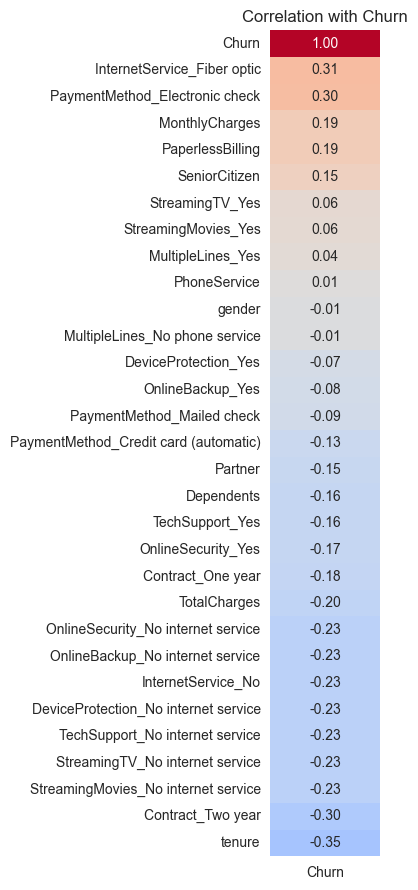

In [33]:
plt.figure(figsize=(4, 9))
sns.heatmap(churn_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, cbar=False)
plt.title('Correlation with Churn'); plt.tight_layout(); plt.show()

**Observation:** matches the EDA - tenure & long contracts reduce churn; fiber, electronic check, monthly charges increase it.

## 13. Multicollinearity (VIF)

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xv = df_enc.drop(columns=['Churn']).replace([np.inf, -np.inf], np.nan).dropna().astype(float)
vif = pd.DataFrame({'feature': Xv.columns,
                    'VIF': [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]}
                   ).sort_values('VIF', ascending=False).reset_index(drop=True)
vif.head(10)

,feature,VIF
0,OnlineBackup_No internet service,inf
1,InternetService_No,inf
2,TechSupport_No internet service,inf
3,DeviceProtection_No internet service,inf
4,StreamingMovies_No internet service,inf
5,OnlineSecurity_No internet service,inf
6,StreamingTV_No internet service,inf
7,PhoneService,1770.644580
8,MonthlyCharges,865.062147
9,InternetService_Fiber optic,148.263380


**Observation:** the "No internet service" dummies are perfectly collinear (VIF = inf) - as predicted in section 4. Tree models are robust to this, so we use them.

## 14. Save the processed data -> `data/processed/`

Persist the fully-encoded, model-ready table and the cleaned (pre-encoding) table for
inspection and reuse.

In [35]:
os.makedirs('data/processed', exist_ok=True)
df_enc.to_csv('data/processed/telco_churn_model_ready.csv', index=False)
df.to_csv('data/processed/telco_churn_processed.csv', index=False)
print('Saved telco_churn_model_ready.csv', df_enc.shape, '(fully encoded)')
print('Saved telco_churn_processed.csv  ', df.shape, '(cleaned, pre-encoding)')

Saved telco_churn_model_ready.csv (7043, 31) (fully encoded)
Saved telco_churn_processed.csv   (7043, 20) (cleaned, pre-encoding)


# Modeling

## 15. Train / test split

In [36]:
from sklearn.model_selection import train_test_split

X = df[CATEGORICAL + NUMERIC].copy()   # RAW columns; the pipeline encodes them
y = df[TARGET].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('Train:', X_train.shape, '| Test:', X_test.shape, '| scale_pos_weight = %.2f' % scale_pos_weight)

Train: (5634, 19) | Test: (1409, 19) | scale_pos_weight = 2.77


### Quantifying the single-row encoding trap

With a split in hand, let's measure how often a naive single-row `drop_first` encoding
would change a prediction versus the correct encoding - i.e. how much damage the trap
would do if it reached serving.

In [37]:
from xgboost import XGBClassifier

FEATURE_COLS = [c for c in df_enc.columns if c != TARGET]
Xa = df_enc[FEATURE_COLS]
xgb_auth = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, n_jobs=-1,
                         random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight, eval_metric='logloss')
xgb_auth.fit(Xa.loc[X_train.index], y_train)

def encode_single_row(d, drop_first):
    x = pd.DataFrame([d]); x.columns = x.columns.str.strip()
    for c in binary_cols:
        if c in x:
            x[c] = x[c].map(binmap)
    obj = list(x.select_dtypes(include='object').columns)
    x = pd.get_dummies(x, columns=obj, drop_first=drop_first)
    for b in x.select_dtypes(include='bool').columns:
        x[b] = x[b].astype(int)
    return x.reindex(columns=FEATURE_COLS, fill_value=0)

flips = internet = 0
for _, r in df.loc[X_test.index, CATEGORICAL + NUMERIC].iterrows():
    rec = r.to_dict()
    if int(xgb_auth.predict(encode_single_row(rec, True))[0]) != int(xgb_auth.predict(encode_single_row(rec, False))[0]):
        flips += 1
        if rec['InternetService'] in ('Fiber optic', 'No'):
            internet += 1
print(f'Holdout customers a naive per-row encoding would mis-score: {flips}/{len(X_test)} ({flips/len(X_test):.1%})')
print(f'  of which Fiber-optic / "No internet": {internet}')

Holdout customers a naive per-row encoding would mis-score: 331/1409 (23.5%)
  of which Fiber-optic / "No internet": 293


Roughly **1 in 4** customers silently mis-scored - invisible to offline metrics. The fitted pipeline removes this entirely.

## 16. Model comparison: RandomForest vs LightGBM vs XGBoost

All trained through the same pipeline, same split, imbalance handled, with a threshold
sweep (recall on churners matters).

In [38]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score

def threshold_sweep(proba, y_true):
    print(f"{'thr':<6}{'prec':<8}{'rec':<8}{'f1':<8}")
    for t in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
        p = (proba >= t).astype(int)
        print(f"{t:<6}{precision_score(y_true,p):<8.3f}{recall_score(y_true,p):<8.3f}{f1_score(y_true,p):<8.3f}")

In [39]:
from sklearn.ensemble import RandomForestClassifier
rf = build_pipeline(RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)).fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]
print('RandomForest  ROC-AUC =', round(roc_auc_score(y_test, proba_rf), 4))
print(classification_report(y_test, (proba_rf >= 0.30).astype(int), digits=3))
threshold_sweep(proba_rf, y_test)

RandomForest  ROC-AUC = 0.8231
              precision    recall  f1-score   support

           0      0.878     0.763     0.817      1035
           1      0.519     0.706     0.598       374

    accuracy                          0.748      1409
   macro avg      0.698     0.735     0.707      1409
weighted avg      0.782     0.748     0.759      1409

thr   prec    rec     f1      
0.25  0.501   0.783   0.611   
0.3   0.519   0.706   0.598   
0.35  0.546   0.655   0.595   
0.4   0.574   0.604   0.589   
0.45  0.599   0.540   0.568   
0.5   0.619   0.473   0.536   


In [40]:
from lightgbm import LGBMClassifier
lgb = build_pipeline(LGBMClassifier(
    n_estimators=500, learning_rate=0.05, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)).fit(X_train, y_train)
proba_lgb = lgb.predict_proba(X_test)[:, 1]
print('LightGBM  ROC-AUC =', round(roc_auc_score(y_test, proba_lgb), 4))
print(classification_report(y_test, (proba_lgb >= 0.30).astype(int), digits=3))
threshold_sweep(proba_lgb, y_test)

LightGBM  ROC-AUC = 0.8285
              precision    recall  f1-score   support

           0      0.910     0.694     0.787      1035
           1      0.489     0.810     0.610       374

    accuracy                          0.725      1409
   macro avg      0.699     0.752     0.698      1409
weighted avg      0.798     0.725     0.740      1409

thr   prec    rec     f1      
0.25  0.474   0.842   0.606   
0.3   0.489   0.810   0.610   
0.35  0.495   0.783   0.607   
0.4   0.511   0.759   0.611   
0.45  0.527   0.722   0.609   
0.5   0.541   0.682   0.604   


In [41]:
xgb = build_pipeline(XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1, scale_pos_weight=scale_pos_weight, eval_metric='logloss')).fit(X_train, y_train)
proba_xgb = xgb.predict_proba(X_test)[:, 1]
print('XGBoost  ROC-AUC =', round(roc_auc_score(y_test, proba_xgb), 4))
print(classification_report(y_test, (proba_xgb >= 0.30).astype(int), digits=3))
threshold_sweep(proba_xgb, y_test)

XGBoost  ROC-AUC = 0.8247
              precision    recall  f1-score   support

           0      0.904     0.698     0.787      1035
           1      0.487     0.794     0.604       374

    accuracy                          0.723      1409
   macro avg      0.695     0.746     0.696      1409
weighted avg      0.793     0.723     0.739      1409

thr   prec    rec     f1      
0.25  0.471   0.832   0.602   
0.3   0.487   0.794   0.604   
0.35  0.496   0.765   0.601   
0.4   0.514   0.733   0.604   
0.45  0.530   0.711   0.607   
0.5   0.546   0.682   0.606   


**Choice: XGBoost** - strong recall, fast, robust to the collinearity from section 13.

## 17. Hyperparameter tuning with Optuna

I tune XGBoost with Optuna on a **validation split carved from the training data** - never
the test set, which stays untouched for honest final reporting. The objective optimises
recall (catching churners); a pure-recall objective biases toward low precision, which is
exactly why the cost-based threshold in section 18 sets the operating point properly.

I also **calibrate** the final model's probabilities (isotonic): `scale_pos_weight` helps
the tree rank well on imbalanced data but inflates its probabilities, and calibration maps
them back to honest values - so the section 18 cost math and the probabilities the app shows can
be trusted.

In [42]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)
spw_fit = (y_fit == 0).sum() / (y_fit == 1).sum()

In [43]:
def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 300, 800),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        subsample=trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
        gamma=trial.suggest_float('gamma', 0.0, 5.0),
        reg_alpha=trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda=trial.suggest_float('reg_lambda', 0.0, 5.0),
        random_state=RANDOM_STATE, n_jobs=-1, scale_pos_weight=spw_fit, eval_metric='logloss')
    pipe = build_pipeline(XGBClassifier(**params)).fit(X_fit, y_fit)
    proba = pipe.predict_proba(X_val)[:, 1]
    return recall_score(y_val, (proba >= 0.30).astype(int))

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=30, show_progress_bar=False)
print('Best validation recall:', round(study.best_value, 4))
study.best_params

Best validation recall: 0.9197


{'n_estimators': 787,
 'learning_rate': 0.12762118849968557,
 'max_depth': 5,
 'subsample': 0.9951560282230606,
 'colsample_bytree': 0.8049580024078398,
 'min_child_weight': 10,
 'gamma': 3.4822708718501234,
 'reg_alpha': 2.7556304465498362,
 'reg_lambda': 4.954199360162043}

In [44]:
from sklearn.calibration import CalibratedClassifierCV

best = dict(study.best_params)
best.update(dict(random_state=RANDOM_STATE, n_jobs=-1, scale_pos_weight=scale_pos_weight, eval_metric='logloss'))
# Wrap the tuned tree in isotonic calibration so probabilities are honest.
final_pipe = build_pipeline(
    CalibratedClassifierCV(XGBClassifier(**best), method='isotonic', cv=5)
).fit(X_train, y_train)
proba_final = final_pipe.predict_proba(X_test)[:, 1]
print('Tuned + calibrated XGBoost  ROC-AUC =', round(roc_auc_score(y_test, proba_final), 4))
print(classification_report(y_test, (proba_final >= 0.35).astype(int), digits=3))

Tuned + calibrated XGBoost  ROC-AUC = 0.8481
              precision    recall  f1-score   support

           0      0.887     0.805     0.844      1035
           1      0.570     0.717     0.635       374

    accuracy                          0.781      1409
   macro avg      0.729     0.761     0.740      1409
weighted avg      0.803     0.781     0.789      1409



## 18. Choosing the decision threshold by business value

Instead of picking a threshold by hand, I choose the one that maximises **expected
retention value**: a caught churner is worth `save_rate*CLV - offer`; a false alarm costs
`offer`; a missed churner costs `CLV`. Because the probabilities are now calibrated, this
optimum lands near the economic break-even, `offer / (CLV|(1+save_rate))`.

In [45]:
from dataclasses import dataclass

@dataclass(frozen=True)
class ChurnEconomics:
    clv: float = 1000.0
    retention_cost: float = 200.0
    save_rate: float = 0.30

def expected_value(y_true, proba, thr, econ):
    y_true = np.asarray(y_true); pred = np.asarray(proba) >= thr
    tp = int(np.sum(pred & (y_true == 1))); fp = int(np.sum(pred & (y_true == 0)))
    fn = int(np.sum(~pred & (y_true == 1)))
    return float(tp * (econ.save_rate * econ.clv - econ.retention_cost)
                 + fp * (-econ.retention_cost) + fn * (-econ.clv))

In [46]:
econ = ChurnEconomics()
proba_val = final_pipe.predict_proba(X_val)[:, 1]      # choose on validation, not test
grid = np.round(np.linspace(0.05, 0.95, 91), 3)
curve = [(t, expected_value(y_val, proba_val, t, econ)) for t in grid]
best_t, best_v = max(curve, key=lambda kv: kv[1])
do_nothing = -int((y_val == 1).sum()) * econ.clv
print(f'Cost-optimal threshold = {best_t:.3f}')
print(f'Uplift vs doing nothing = ${best_v - do_nothing:,.0f}')
print(f"Value at a fixed 0.35 = ${expected_value(y_val, proba_val, 0.35, econ):,.0f}")

Cost-optimal threshold = 0.140
Uplift vs doing nothing = $248,100
Value at a fixed 0.35 = $-84,900


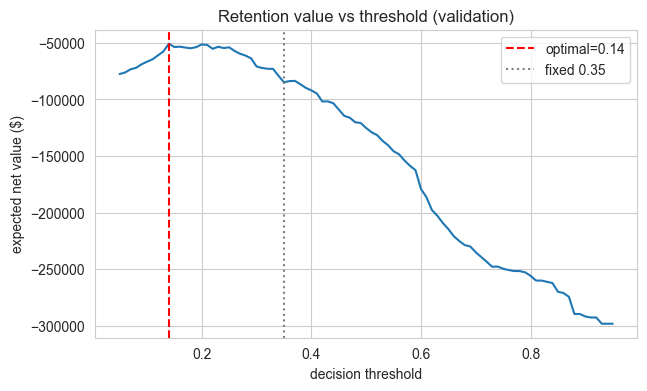

In [47]:
ts = [t for t, _ in curve]; vs = [v for _, v in curve]
plt.figure(figsize=(7, 4)); plt.plot(ts, vs)
plt.axvline(best_t, color='red', ls='--', label=f'optimal={best_t:.2f}')
plt.axvline(0.35, color='gray', ls=':', label='fixed 0.35')
plt.xlabel('decision threshold'); plt.ylabel('expected net value ($)')
plt.title('Retention value vs threshold (validation)'); plt.legend(); plt.show()

In [48]:
print('Holdout performance at the cost-optimal threshold %.2f:' % best_t)
print(classification_report(y_test, (proba_final >= best_t).astype(int), digits=3))

Holdout performance at the cost-optimal threshold 0.14:
              precision    recall  f1-score   support

           0      0.947     0.602     0.736      1035
           1      0.451     0.906     0.603       374

    accuracy                          0.683      1409
   macro avg      0.699     0.754     0.669      1409
weighted avg      0.815     0.683     0.701      1409



## 19. Explaining a prediction with SHAP

A probability is only actionable if you know *why*. SHAP attributes one customer's score
to individual features, which I turn into a concrete recommended retention action.

In [49]:
import shap
prep = final_pipe.named_steps['prep']
estimator = final_pipe.named_steps['model']
# the final step is a calibrated wrapper; SHAP needs the underlying tree model
xgb_model = (estimator.calibrated_classifiers_[0].estimator
             if hasattr(estimator, 'calibrated_classifiers_') else estimator)
feat_names = prep.get_feature_names_out()

# Pick a high-risk holdout customer to explain.
hi = int(np.argmax(proba_final))
customer = df.loc[X_test.index, CATEGORICAL + NUMERIC].iloc[[hi]]
print('Predicted churn probability:', round(float(proba_final[hi]), 4))

Predicted churn probability: 1.0


In [50]:
shap_vals = shap.TreeExplainer(xgb_model).shap_values(prep.transform(customer))[0]

def base_feature(name):
    name = name.split('__', 1)[1] if '__' in name else name
    for col in CATEGORICAL:
        if name.startswith(col + '_'):
            return col
    return name

# Sum SHAP across the one-hot columns of each original feature; label with the customer's value.
cust_row = customer.iloc[0]
totals = {}
for name, val in zip(feat_names, shap_vals):
    b = base_feature(name)
    totals[b] = totals.get(b, 0.0) + float(val)
drivers = pd.DataFrame([
    {'feature': f"{b} = {cust_row[b]}" if b in CATEGORICAL else b, 'shap_value': round(t, 4)}
    for b, t in totals.items()
])
drivers = (drivers.assign(_a=drivers['shap_value'].abs())
                  .sort_values('_a', ascending=False).drop(columns='_a').head(8).reset_index(drop=True))
drivers

,feature,shap_value
0,Contract = Month-to-month,0.6522
1,tenure,0.5914
2,InternetService = Fiber optic,0.2370
3,OnlineSecurity = No,0.1787
4,TechSupport = No,0.1741
5,TotalCharges,0.1490
6,MonthlyCharges,0.1144
7,MultipleLines = Yes,0.1091


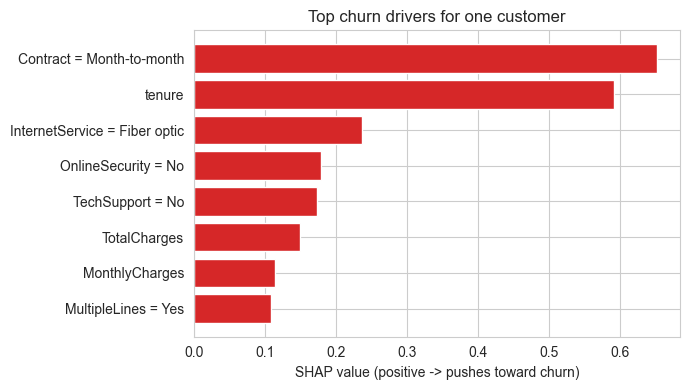

In [51]:
plt.figure(figsize=(7, 4))
colors = ['#d62728' if v > 0 else '#2ca02c' for v in drivers['shap_value']]
plt.barh(drivers['feature'][::-1], drivers['shap_value'][::-1], color=colors[::-1])
plt.xlabel('SHAP value (positive -> pushes toward churn)')
plt.title('Top churn drivers for one customer'); plt.tight_layout(); plt.show()

## 20. Data validation contract (pandera)

I express the data's business rules as a declarative **pandera** schema (allowed category
values, numeric ranges). It guards the pipeline against malformed inputs and doubles as a
test fixture.

In [52]:
import pandera.pandas as pa
from pandera.pandas import Check, Column, DataFrameSchema

yn = Check.isin(['Yes', 'No'])
SCHEMA = DataFrameSchema({
    'customerID': Column(str, nullable=False, unique=True),
    'gender': Column(str, Check.isin(['Male', 'Female'])),
    'SeniorCitizen': Column(int, Check.isin([0, 1]), coerce=True),
    'Partner': Column(str, yn), 'Dependents': Column(str, yn), 'PhoneService': Column(str, yn),
    'InternetService': Column(str, Check.isin(['DSL', 'Fiber optic', 'No'])),
    'Contract': Column(str, Check.isin(['Month-to-month', 'One year', 'Two year'])),
    'tenure': Column(int, Check.in_range(0, 120), coerce=True),
    'MonthlyCharges': Column(float, Check.in_range(0, 200), coerce=True),
    'TotalCharges': Column(float, Check.ge(0), nullable=True, coerce=True),
}, strict=False)

check = raw.copy(); check.columns = check.columns.str.strip()
check['TotalCharges'] = pd.to_numeric(check['TotalCharges'], errors='coerce')
try:
    SCHEMA.validate(check, lazy=True)
    print('Data contract PASSED.')
except pa.errors.SchemaErrors as e:
    print('Violations:', sorted(set(e.failure_cases['column'].dropna())))

Data contract PASSED.


## 21. Experiment tracking (MLflow)

I log the **whole fitted pipeline** (the exact serving artifact) plus the chosen threshold
to a local MLflow store, so every run's parameters, metrics and model are reproducible.

In [53]:
from pathlib import Path
import mlflow, mlflow.sklearn
try:
    mlflow.set_tracking_uri(Path('mlruns').resolve().as_uri())     # valid file:/// on Windows too
    mlflow.set_experiment('Telco Churn - notebook')
    with mlflow.start_run(run_name='notebook_pipeline'):
        mlflow.log_params(study.best_params)
        mlflow.log_param('threshold', round(best_t, 3))
        mlflow.log_metric('roc_auc', float(roc_auc_score(y_test, proba_final)))
        mlflow.log_metric('recall', float(recall_score(y_test, (proba_final >= best_t).astype(int))))
        mlflow.sklearn.log_model(final_pipe, 'model')
    print('Logged full pipeline to ./mlruns (experiment "Telco Churn - notebook").')
except Exception as e:
    print('MLflow logging skipped:', e)

Traceback (most recent call last):
  File "C:\Users\heman\anaconda3\envs\ml_churn\Lib\site-packages\mlflow\store\tracking\file_store.py", line 317, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\heman\anaconda3\envs\ml_churn\Lib\site-packages\mlflow\store\tracking\file_store.py", line 410, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\heman\anaconda3\envs\ml_churn\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1341, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\heman\anaconda3\envs\ml_churn\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1334, in _read_helper
    result = read_yaml(root, file_name)
    

Logged full pipeline to ./mlruns (experiment "Telco Churn - notebook").


## 22. Summary & verdict

- **EDA** revealed an imbalanced target (~26.5%), clean categories, one data-quality issue
  (`TotalCharges` blanks = tenure-0 customers -> 0), and strong churn signal from tenure,
  contract type, internet service and payment method.
- **Models** all land around **ROC-AUC ~0.83**; Optuna lifts the tuned XGBoost to ~**0.85**.
  XGBoost is the pick - fast and robust to the VIF collinearity.
- **What this project optimises for:** correctness, sound decisions, and explainability -
  not a marginally higher offline AUC:
  - **Serving correctness:** one fitted pipeline encodes a request exactly as in training;
    section 15 shows a naive single-row encoding would mis-score ~1 in 4 customers.
  - **Calibrated, honest probabilities:** the final model is isotonic-calibrated, so a
    predicted "34%" means a real 34% (uncalibrated, `scale_pos_weight` inflated it); the
    cost-optimal threshold then lands at the economic break-even.
  - **Decision quality:** the threshold is chosen by expected value, not guessed.
  - **Explainability:** per-prediction SHAP, aggregated to the customer's actual feature
    values; plus a data contract that runs in CI.
- **Honest caveats:** the retention economics (CLV, offer, save-rate) are assumptions that
  set how aggressively customers are flagged, and these are single-split numbers
  (cross-validation would add confidence intervals).